##  IMPA Tech - IMPA - Instituto de Matemática Pura e Aplicada

### Participantes: Natália e Heitor

## Análise em Python sobre os casos de VSR no Brasil 
  



### O objetivo deste trabalho consiste em analisar o comportamento do Vírus Sincicial Respiratório (VSR) no Brasil utilizando dados do InfoGripe. Inicialmente, foi feito um panorama geral da evolução dos casos ao longo dos anos. Em seguida, foi realizada uma análise por estado,  por meio da incidência por 100 mil habitantes e discutidos diferentes critérios para identificar semanas epidêmicas. Além disso, esta análise tem como intuito verificar a eficiência do nosso método de classificação de epidemias baseado em três notícias sobre os seguintes estados: Mato Grosso do Sul, Rio de Janeiro e Rio Grande do Sul. 

https://www.cnnbrasil.com.br/nacional/sul/rs/rs-decreta-emergencia-por-aumento-de-internacoes-por-doencas-respiratorias/

https://www.campograndenews.com.br/saude-e-bem-estar/ms-registra-quase-tres-mortes-diarias-por-sindrome-respiratoria-aguda-grave

https://news.cremerj.org.br/2025/07/10/casos-de-sindrome-respiratoria-grave-seguem-em-alta-no-rio/

## Bibliotecas necessárias

In [556]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Carregando a base de dados 

In [557]:

url = "https://github.com/infogripe/Boletim_InfoGripe/raw/refs/heads/main/Dados/InfoGripe/casos_semanais_fx_etaria_virus_sem_filtro_febre.csv"

df = pd.read_csv(url, sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182294 entries, 0 to 182293
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   SG_UF_NOT              182294 non-null  int64
 1   fx_etaria              182294 non-null  str  
 2   SRAG                   182294 non-null  int64
 3   SARS2                  182294 non-null  int64
 4   VSR                    182294 non-null  int64
 5   FLU                    182294 non-null  int64
 6   FLU_A                  182294 non-null  int64
 7   FLU_AH1N1              182294 non-null  int64
 8   FLU_AH3N2              182294 non-null  int64
 9   FLU_ANSUBTPD           182294 non-null  int64
 10  FLU_ANSUBTPV           182294 non-null  int64
 11  FLU_AINC               182294 non-null  int64
 12  FLU_AOUT               182294 non-null  int64
 13  FLU_B                  182294 non-null  int64
 14  FLU_BVIC               182294 non-null  int64
 15  FLU_BYAM               18229

C:\Users\Lya\AppData\Local\Temp\ipykernel_4204\741302333.py:3: DtypeWarning: Columns (0: DS_UF_SIGLA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, sep=";")


In [558]:
df.head()

,SG_UF_NOT,fx_etaria,SRAG,SARS2,VSR,FLU,FLU_A,FLU_AH1N1,FLU_AH3N2,FLU_ANSUBTPD,...,PARA4,OUTROS,positivos,negativos,aguardando,DS_UF_SIGLA,epiyear,epiweek,Semana epidemiológica,Ano epidemiológico
0,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,16,16,2009
1,0,< 2,3,0,0,1,1,0,0,0,...,0,1,2,0,0,BR,2009,17,17,2009
2,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,18,18,2009
3,0,< 2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,BR,2009,19,19,2009
4,0,< 2,1,0,0,0,0,0,0,0,...,0,0,0,1,0,BR,2009,20,20,2009


## Analisando os casos de vsr (ignorando a faixa etária) de 2009 - 2026 

In [559]:
vsr = (
    df.groupby(
        ["DS_UF_SIGLA", "epiyear", "epiweek"]
    )["VSR"]
    .sum()
    .reset_index()
)

vsr.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0


## Limpeza dos dados 

In [560]:
vsr.info()

<class 'pandas.DataFrame'>
RangeIndex: 25144 entries, 0 to 25143
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   DS_UF_SIGLA  25144 non-null  str  
 1   epiyear      25144 non-null  int64
 2   epiweek      25144 non-null  int64
 3   VSR          25144 non-null  int64
dtypes: int64(3), str(1)
memory usage: 838.1 KB


In [561]:
# checando se há valores duplicados
vsr.duplicated().sum()

np.int64(0)

In [562]:
# checando se não há estados estranhos 
sorted(vsr["DS_UF_SIGLA"].unique())

['AC',
 'AL',
 'AM',
 'AP',
 'BA',
 'BR',
 'CE',
 'DF',
 'ES',
 'GO',
 'MA',
 'MG',
 'MS',
 'MT',
 'PA',
 'PB',
 'PE',
 'PI',
 'PR',
 'RJ',
 'RN',
 'RO',
 'RR',
 'RS',
 'SC',
 'SE',
 'SP',
 'TO']

In [563]:
# checando se as semanas epidemiológicas são válidas
vsr["epiweek"].describe()

count    25144.000000
mean        26.521158
std         14.986190
min          1.000000
25%         14.000000
50%         26.000000
75%         39.000000
max         53.000000
Name: epiweek, dtype: float64

In [564]:
# checando se há casos negativos 
(vsr["VSR"] < 0).sum()

np.int64(0)

Antes da análise, a base foi inspecionada para verificar possíveis problemas nos dados. Não foram encontrados valores nulos ou inconsistências nas variáveis utilizadas.

### Visualizando os dados de 2009 e 2010

In [565]:
vsr[vsr["epiyear"] == 2009]

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2009,16,0
1,AC,2009,17,0
2,AC,2009,18,0
3,AC,2009,19,0
4,AC,2009,20,0
...,...,...,...,...
24278,TO,2009,48,0
24279,TO,2009,49,0
24280,TO,2009,50,0
24281,TO,2009,51,0


In [566]:
vsr[vsr["epiyear"] == 2010]

,DS_UF_SIGLA,epiyear,epiweek,VSR
37,AC,2010,1,0
38,AC,2010,2,0
39,AC,2010,3,0
40,AC,2010,4,0
41,AC,2010,5,0
...,...,...,...,...
24330,TO,2010,48,0
24331,TO,2010,49,0
24332,TO,2010,50,0
24333,TO,2010,51,0


Note que a cada ano tem a semana 1, 2, ..., para facilitar nossa análise, adicionaremos uma nova coluna de forma que o número da semana seja crescente.

In [567]:
# ignorando os estados por enquanto
vsr_global = (
    vsr.groupby(["epiyear", "epiweek"])["VSR"]
       .sum()
       .reset_index()
)

vsr_global.head()

,epiyear,epiweek,VSR
0,2009,16,0
1,2009,17,0
2,2009,18,0
3,2009,19,0
4,2009,20,0


In [568]:
# adicioanndo nova coluna 
vsr_global["semana_global"] = range(1, len(vsr_global) + 1)

vsr_global

,epiyear,epiweek,VSR,semana_global
0,2009,16,0,1
1,2009,17,0,2
2,2009,18,0,3
3,2009,19,0,4
4,2009,20,0,5
...,...,...,...,...
893,2026,22,7872,894
894,2026,23,6952,895
895,2026,24,5708,896
896,2026,25,3364,897


### Panorama geral de casos de VSR no Brasil no período de 2009 a 2026

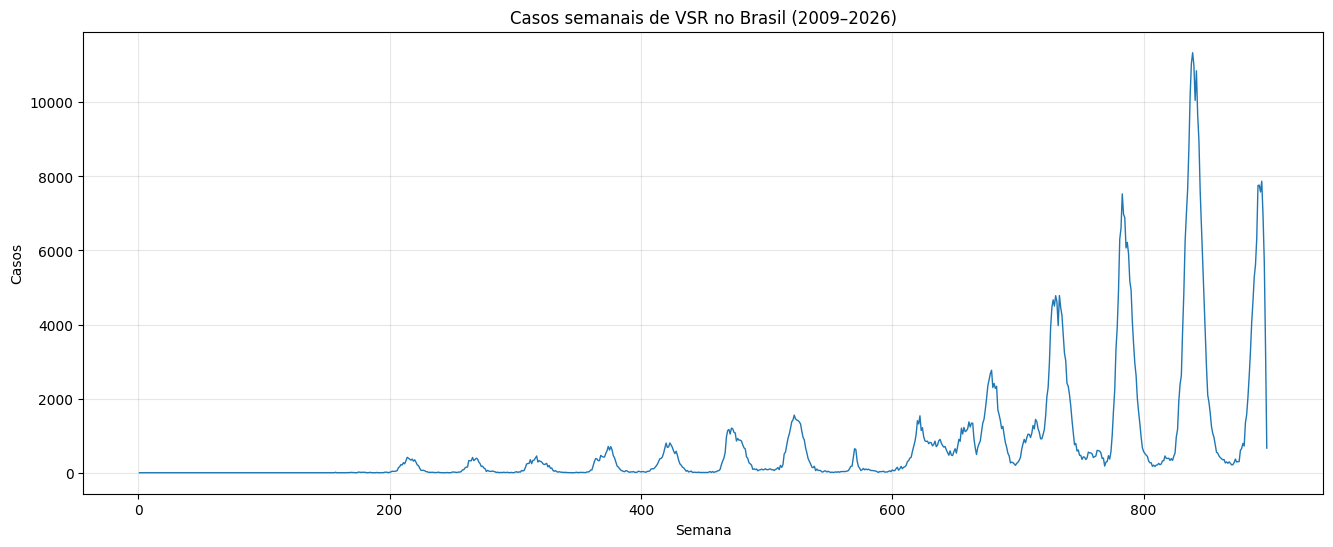

In [569]:
plt.figure(figsize=(16,6))

plt.plot(
    vsr_global["semana_global"],
    vsr_global["VSR"],
    linewidth=1
)

plt.title("Casos semanais de VSR no Brasil (2009–2026)")
plt.xlabel("Semana")
plt.ylabel("Casos")
plt.grid(alpha=0.3)

plt.show()

In [570]:
vsr_global[vsr_global["semana_global"] == 600]

,epiyear,epiweek,VSR,semana_global
599,2020,42,76,600


É notório que os casos de VSR apresentam picos anuais ao longo de toda a série, porém esses picos se tornam muito maiores a partir de 2019, principalmente nos anos mais recentes. É importante ressaltar que esse aumento não significa necessariamente que a circulação do vírus tenha aumentado. Uma possível explicação para isso é que o sistema de vigilância passou por um processo de consolidação a partir de 2019, tornando os registros mais confiáveis.

## População

In [571]:
url = "https://apisidra.ibge.gov.br/values/t/6579/n3/all/v/9324/p/2019,2022,2023,2024,2025?formato=json"

pop = pd.read_json(url)

pop.head()

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Unidade da Federação (Código),Unidade da Federação,Variável (Código),Variável,Ano (Código),Ano
1,3,Unidade da Federação,45,Pessoas,1777225,11,Rondônia,9324,População residente estimada,2019,2019
2,3,Unidade da Federação,45,Pessoas,1746227,11,Rondônia,9324,População residente estimada,2024,2024
3,3,Unidade da Federação,45,Pessoas,1751950,11,Rondônia,9324,População residente estimada,2025,2025
4,3,Unidade da Federação,45,Pessoas,881935,12,Acre,9324,População residente estimada,2019,2019


### Limpeza

In [572]:
pop = pop.iloc[1:].copy()   # Remove a primeira linha (descrição)

In [573]:
pop = pop[["D1N", "D3N", "V"]] # filtrando apenas as colunas necessárias

In [574]:
pop.columns = ["estado", "epiyear", "populacao"] # renomeando as colunas

In [575]:
pop["epiyear"] = pop["epiyear"].astype(int)     # deixando o tipo da coluna adequado
pop["populacao"] = pop["populacao"].astype(int)

In [576]:
siglas = {
    "Rondônia": "RO",
    "Acre": "AC",
    "Amazonas": "AM",
    "Roraima": "RR",
    "Pará": "PA",
    "Amapá": "AP",
    "Tocantins": "TO",
    "Maranhão": "MA",
    "Piauí": "PI",
    "Ceará": "CE",
    "Rio Grande do Norte": "RN",
    "Paraíba": "PB",
    "Pernambuco": "PE",
    "Alagoas": "AL",
    "Sergipe": "SE",
    "Bahia": "BA",
    "Minas Gerais": "MG",
    "Espírito Santo": "ES",
    "Rio de Janeiro": "RJ",
    "São Paulo": "SP",
    "Paraná": "PR",
    "Santa Catarina": "SC",
    "Rio Grande do Sul": "RS",
    "Mato Grosso do Sul": "MS",
    "Mato Grosso": "MT",
    "Goiás": "GO",
    "Distrito Federal": "DF"
}

pop["DS_UF_SIGLA"] = pop["estado"].map(siglas)

In [577]:
pop = pop.drop(columns="estado") # trocando nomes por siglas

In [578]:
pop.head()

,epiyear,populacao,DS_UF_SIGLA
1,2019,1777225,RO
2,2024,1746227,RO
3,2025,1751950,RO
4,2019,881935,AC
5,2024,880631,AC


In [579]:
len(pop)

81

A tabela de estimativas populacionais do IBGE fornece os dados para 2019, 2024 e 2025. Os anos de 2022 e 2023 não fazem parte dessa série, pois nesse período foi realizado o Censo Demográfico 2022, cuja coleta ocorreu entre 2022 e 2023. Por esse motivo, a população de 2022 foi obtida diretamente dos dados do Censo. Como não há uma estimativa anual separada para 2023 na mesma série utilizada, adotamos a população de 2022 também para 2023, já que a variação populacional entre esses dois anos é pequena.

In [580]:
pop2022 = pd.read_excel("tabela4709.xlsx")

### Limpeza

In [581]:
pop2022 = pd.read_excel("tabela4709.xlsx", skiprows=3) #removendo linhas inúteis

# filtrando apenas as variáveis que queremos
pop2022 = pop2022.iloc[:, [1, 2]]
pop2022.columns = ["estado", "populacao"]

# garantindo que só tem apenas população de estados
pop2022 = pop2022[pop2022["estado"] != "Brasil"]

# remove linhas nulas
pop2022 = pop2022.dropna()

In [582]:
# acrescenta ano 2022
pop2022["epiyear"] = 2022

# cria o df de 2023 igual o de 2022
pop2023 = pop2022.copy()
pop2023["epiyear"] = 2023

pop2022["DS_UF_SIGLA"] = pop2022["estado"].map(siglas)
pop2023["DS_UF_SIGLA"] = pop2023["estado"].map(siglas)

In [583]:
# troca nomes dos estados por siglas
pop2022 = pop2022[["epiyear", "populacao", "DS_UF_SIGLA"]]
pop2023 = pop2023[["epiyear", "populacao", "DS_UF_SIGLA"]]

In [584]:
# junta dados de 2022 e 2023
pop = pd.concat([pop, pop2022, pop2023], ignore_index=True)

In [585]:
# ordena por estados
pop = pop.sort_values(
    ["DS_UF_SIGLA", "epiyear"]
).reset_index(drop=True)

In [586]:
pop

,epiyear,populacao,DS_UF_SIGLA
0,2019,881935.0,AC
1,2022,830018.0,AC
2,2023,830018.0,AC
3,2024,880631.0,AC
4,2025,884372.0,AC
...,...,...,...
130,2019,1572866.0,TO
131,2022,1511460.0,TO
132,2023,1511460.0,TO
133,2024,1577342.0,TO


Filtramos os anos de 2018 a 2026, pois a construção da amostra
utiliza os anos de 2019, 2022, 2023, 2024 e 2025, além das semanas
vizinhas. Assim, 2018 e 2026 são mantidos para permitir o tratamento
das semanas de borda (1 e 52).

In [587]:
vsr_filtrado = vsr[
    ((2018 <= vsr["epiyear"]) &(vsr["epiyear"] <= 2026))
].copy()
vsr_filtrado = vsr_filtrado.reset_index(drop=True)
vsr_filtrado.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR
0,AC,2018,1,0
1,AC,2018,2,0
2,AC,2018,3,2
3,AC,2018,4,0
4,AC,2018,5,0


Como a incidência é calculada dividindo o número de casos pela população, os valores obtidos são muito pequenos e acabam sendo difíceis de interpretar. Por isso, multiplicamos o resultado por 100.000, passando a trabalhar com o número de casos por 100 mil habitantes.

In [588]:
# 1. Criar uma cópia do dataframe de população para não alterar o original
pop_ajustada = pop.copy()

# 2. Replicar os dados de 2019 para o ano de 2018
pop_2018 = pop_ajustada[pop_ajustada["epiyear"] == 2019].copy()
pop_2018["epiyear"] = 2018

# 3. Replicar os dados de 2025 para o ano de 2026
pop_2026 = pop_ajustada[pop_ajustada["epiyear"] == 2025].copy()
pop_2026["epiyear"] = 2026

pop_2020 = pop_ajustada[pop_ajustada["epiyear"] == 2019].copy()
pop_2020["epiyear"] = 2020

pop_2021 = pop_ajustada[pop_ajustada["epiyear"] == 2022].copy()
pop_2021["epiyear"] = 2021

# 4. Juntar as novas linhas ao dataframe de população original
pop_ajustada = pd.concat(
    [pop_ajustada, pop_2018, pop_2026, pop_2021, pop_2020], ignore_index=True
)

# 5. Combinar (merge) os dois DataFrames usando o Estado e o Ano como chaves
vsr_filtrado = vsr_filtrado.merge(
    pop_ajustada, on=["DS_UF_SIGLA", "epiyear"], how="left"
)

# 6. Criar a coluna de incidência por 100 mil habitantes
vsr_filtrado["incidencia_por_100k"] = (
    vsr_filtrado["VSR"] * 100000 / vsr_filtrado["populacao"]
)

# Visualizar o resultado
vsr_filtrado.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,AC,2018,1,0,881935.0,0.000000
1,AC,2018,2,0,881935.0,0.000000
2,AC,2018,3,2,881935.0,0.226774
3,AC,2018,4,0,881935.0,0.000000
4,AC,2018,5,0,881935.0,0.000000


## Análise de VSR de 2019 - 2025

Nosso objetivo consiste em realizar 3 filtros para determinar se uma dada semana foi ou não uma epidemia.

Como nossa análise considera cinco anos (2019, 2022, 2023, 2024 e 2025), em vez de analisar apenas a semana x, utilizaremos também as semanas x−2, x−1, x, x+1 e x+2. Dessa forma, a amostra deixa de ter apenas 5 observações e passa a conter 25 observações.

Note que 2020 e 2021 não estão inclusos em nossa análise devido serem anos pandêmicos.

In [589]:
vsr_filtrado.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,AC,2018,1,0,881935.0,0.000000
1,AC,2018,2,0,881935.0,0.000000
2,AC,2018,3,2,881935.0,0.226774
3,AC,2018,4,0,881935.0,0.000000
4,AC,2018,5,0,881935.0,0.000000


In [590]:
vsr_filtrado['epiyear'].info()

<class 'pandas.Series'>
RangeIndex: 12432 entries, 0 to 12431
Series name: epiyear
Non-Null Count  Dtype
--------------  -----
12432 non-null  int64
dtypes: int64(1)
memory usage: 97.3 KB


Essa função recebe a sigla de um estado e retorna um novo DataFrame contendo apenas os dados desse estado.

In [591]:
def filtrar_estado(x):
  saida = vsr_filtrado[ (vsr_filtrado['DS_UF_SIGLA'] == x)].copy()
  saida = saida.reset_index(drop=True)
  return saida

In [592]:
MS = filtrar_estado('MS')

A função filtrar_ano recebe um DataFrame e um ano epidemiológico como parâmetros, retornando apenas os registros correspondentes a esse ano.

In [593]:
def filtrar_ano(x,n):
  saida = x[ (x['epiyear'] == n)].copy()
  saida = saida.reset_index(drop=True)
  return saida


In [594]:
filtrar_ano(MS,2019)

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,MS,2019,1,8,2778986.0,0.287875
1,MS,2019,2,10,2778986.0,0.359843
2,MS,2019,3,14,2778986.0,0.503781
3,MS,2019,4,6,2778986.0,0.215906
4,MS,2019,5,18,2778986.0,0.647718
5,MS,2019,6,16,2778986.0,0.575750
6,MS,2019,7,10,2778986.0,0.359843
7,MS,2019,8,12,2778986.0,0.431812
8,MS,2019,9,18,2778986.0,0.647718
9,MS,2019,10,24,2778986.0,0.863624


A função filtrar_amostra constrói uma amostra de valores de VSR em torno de uma semana epidemiológica específica. Para cada um dos anos analisados (2019 e 2022–2025), são coletados os casos correspondentes à semana de interesse e às duas semanas anteriores e posteriores, formando uma janela de cinco semanas. Nos casos em que a janela ultrapassa o início ou o fim do ano, a função utiliza as semanas correspondentes do ano anterior ou seguinte, garantindo que a amostra seja sempre composta por cinco semanas consecutivas. Ao final, todos os valores são reunidos em uma única lista e retornados.

In [595]:
def filtrar_amostra(x,n):
  amostra = []
  if n==1:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      N=filtrar_ano(x,i-1)
      amostra.append(float(N.loc[N['epiweek'] == 51, 'incidencia_por_100k'].values[0]))
      amostra.append(float(N.loc[N['epiweek'] == 52, 'incidencia_por_100k'].values[0]))
      for j in range(n, n+3):
        amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
  elif n==2:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      N=filtrar_ano(x,i-1)
      amostra.append(float(N.loc[N['epiweek'] == 52, 'incidencia_por_100k'].values[0]))
      for j in range(n-1, n+3):
        amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
  elif n>=3 and n<=50:
    for i in [2019, 2022,2023,2024,2025]:
      M=filtrar_ano(x,i)
      for j in range(n-2, n+3):
        amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
  elif n==51:
    for i in [2019, 2022,2023,2024]:
        M=filtrar_ano(x,i)
        N=filtrar_ano(x,i+1)
        for j in range(n-2, n+2):
          amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
        amostra.append(float(N.loc[N['epiweek'] == 1, 'incidencia_por_100k'].values[0]))
    M=filtrar_ano(x,2025)
    for j in range(n-2, n+3):
        amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
  else:
    for i in [2019, 2022,2023,2024]:
        M=filtrar_ano(x,i)
        N=filtrar_ano(x,i+1)
        for j in range(n-2, n+1):
          amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
        amostra.append(float(N.loc[N['epiweek'] == 1, 'incidencia_por_100k'].values[0]))
        amostra.append(float(N.loc[N['epiweek'] == 2, 'incidencia_por_100k'].values[0]))
    M=filtrar_ano(x,2025)
    N=filtrar_ano(x,2026)
    for j in range(n-2, n+2):
        amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))
    amostra.append(float(N.loc[N['epiweek'] == 1, 'incidencia_por_100k'].values[0]))
  return amostra

In [596]:
filtrar_amostra(MS,45)

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.07254227673210101,
 0.07254227673210101,
 0.0,
 0.07254227673210101,
 0.0,
 0.0,
 0.0,
 0.0,
 0.14508455346420202,
 0.0,
 0.0,
 0.06892048127172072,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06838469536840716,
 0.0]

Filtro 1)  Vamos estabelecer uma incidência mínima nessa semana, ela vai ser dado um periodo x, a média + 2*desvio padrão. 

O primeiro filtro serve para verificar se a incidência observada é realmente alta ou se ainda está dentro da variação normal do vírus. Para isso, utilizamos um período do ano em que normalmente há baixa circulação viral e calculamos a média e o desvio padrão das incidências nesse período. Em seguida, definimos um limiar igual à média mais duas vezes o desvio padrão. Assim, apenas semanas cuja incidência está significativamente acima do comportamento esperado passam para os próximos filtros. 

Esse é um critério estatístico para identificar valores incomuns. A média representa o comportamento normal, enquanto o desvio padrão mede a variabilidade. Quando um valor ultrapassa a média mais dois desvios-padrão, ele tende a estar bem acima do esperado, sendo um forte candidato a representar um comportamento anormal, como o início de uma epidemia.

In [597]:
def filtro1(x):
  amostra=[]
  for i in [2019, 2022,2023,2024,2025]:
    M=filtrar_ano(x,i)
    for j in range(35, 53):
      amostra.append(float(M.loc[M['epiweek'] == j, 'incidencia_por_100k'].values[0]))

  media = np.mean(amostra)
  desvio_padrao = np.std(amostra, ddof=1)
  saida = media + (2 * desvio_padrao)
  return float(saida)

In [598]:
filtro1(MS)

0.15031527154526758

Filtro 2) Com os dados dessas 25 semanas, é calculado a média. A incidência precisa estar acima de 1.5*média.

A função filtro2 calcula um limiar para uma determinada semana epidemiológica. Primeiro, obtém a amostra de casos de VSR por meio da função filtrar_amostra. Em seguida, calcula a média dos valores dessa amostra e define o limiar como 1,5 vezes essa média. O valor resultante é retornado e é utilizado como critério para identificar semanas com atividade epidêmica acima do esperado.

In [599]:
def filtro2(x,n):
  amostra = filtrar_amostra(x,n)
  media = sum(amostra)/len(amostra)
  saida = 1.5*media
  return saida

In [600]:
Teste1 = []
for i in range(1,53):
  Teste1.append(filtro2(MS,i))
Teste1

[0.5197598645922994,
 0.424324611476088,
 0.3542624968605508,
 0.30139548859307586,
 0.29729240687097147,
 0.36164919837095444,
 0.5970659746720549,
 0.861275420316227,
 1.3584053372528069,
 2.047343309491155,
 3.0472164567700517,
 3.9983239293009567,
 4.8724838616584325,
 5.62684579695933,
 6.125761786499899,
 6.279575587627392,
 6.39817745445283,
 6.4262112816327495,
 6.314997923384885,
 6.00860004855678,
 5.66572583868882,
 4.955093069723808,
 4.373855174966343,
 3.52057971965741,
 2.899354993260889,
 2.203036072639944,
 1.7894740775822437,
 1.3054846935516247,
 1.00818031441879,
 0.7113050960494134,
 0.5220268252229796,
 0.35300678577347744,
 0.21199982323920907,
 0.16167311690403477,
 0.12856686109117887,
 0.09552489958672064,
 0.06195414882440123,
 0.03705632411573512,
 0.029430986566054338,
 0.021224823121845485,
 0.017306901973165055,
 0.02579466745339436,
 0.02579466745339436,
 0.03000099361803797,
 0.03000099361803797,
 0.029783685890415156,
 0.025431149286489096,
 0.03413622

FIltro 3) Os casos dessa semana precisam estar acima da percentil 80 dessas 25 semanas.

A função filtro3 calcula um limiar baseado na distribuição dos dados da amostra. Inicialmente, obtém a amostra por meio da função filtrar_amostra e ordena seus valores em ordem crescente. Em seguida, retorna o elemento de índice 19, isto é, o 20º menor valor da amostra (que possui 25 elementos). Esse valor corresponde aproximadamente ao 80º percentil da amostra e pode ser utilizado como um limiar para identificar semanas com número de casos acima do padrão observado.

In [601]:
def filtro3(x,n):
  amostra = filtrar_amostra(x,n)
  amostra.sort()
  saida = amostra[19]
  return saida

In [602]:
Teste2 =[]
for i in range(1,53):
  Teste2.append(filtro3(MS,i))
Teste2

[0.4318121789746332,
 0.29016910692840403,
 0.359843482478861,
 0.36271138366050504,
 0.36271138366050504,
 0.36271138366050504,
 0.6154622583156645,
 0.7254227673210101,
 1.230924516631329,
 1.7780020795785862,
 2.3934643378942506,
 4.445005198946466,
 5.265621543367351,
 6.601347182621192,
 6.906854232209123,
 6.906854232209123,
 6.906854232209123,
 6.906854232209123,
 5.368128478175475,
 5.306877057922495,
 5.306877057922495,
 5.306877057922495,
 5.306877057922495,
 4.10308172210443,
 3.6927735498939867,
 2.550057807053667,
 1.7780020795785862,
 1.5728479934733646,
 1.3094891441626937,
 0.7581252939889279,
 0.5470775629472573,
 0.41030817221044297,
 0.20515408610522148,
 0.13784096254344144,
 0.13784096254344144,
 0.13784096254344144,
 0.13676939073681432,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06838469536840716,
 0.06838469536840716,
 0.06838469536840716,
 0.0,
 0.06838469536840716,
 0.06838469536840716,
 0.06892048127172072,
 0.06892048127172072,
 0.13676939073681432]

### Mato Grosso do Sul

In [603]:
MS = filtrar_estado('MS')
MS.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,MS,2018,1,0,2778986.0,0.0
1,MS,2018,2,0,2778986.0,0.0
2,MS,2018,3,0,2778986.0,0.0
3,MS,2018,4,0,2778986.0,0.0
4,MS,2018,5,0,2778986.0,0.0


In [604]:
#Filtro 1

ft1 = filtro1(MS)
ft1

0.15031527154526758

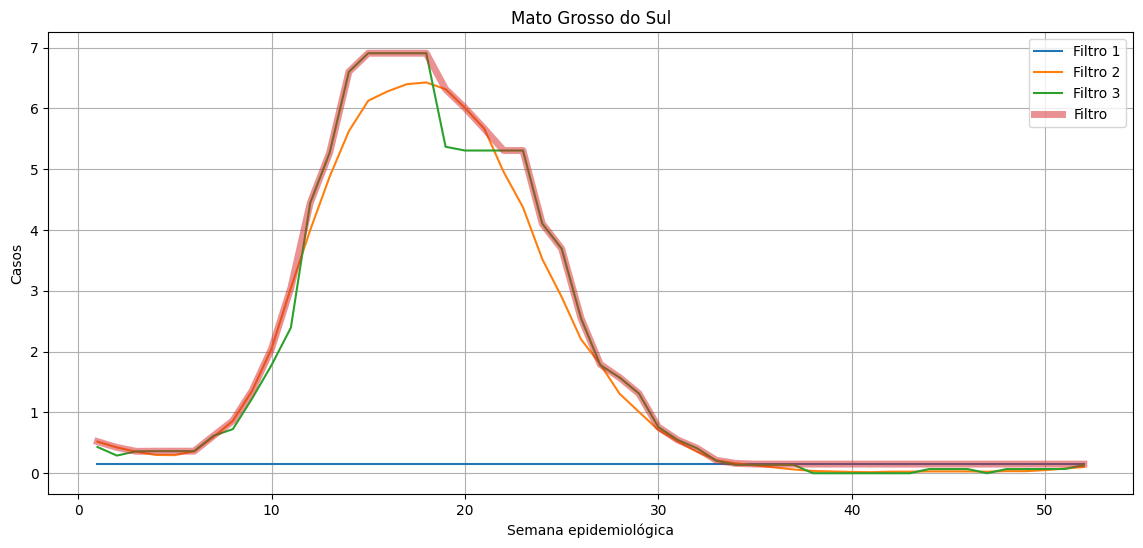

In [605]:
M = filtrar_ano(MS, 2019)

semanas = []
f1 = []
f2 = []
f3 = []
f = []

for semana in range(1, 53):

    semanas.append(semana)

    f1.append(ft1)          # valor fixo
    f2.append(filtro2(MS, semana))
    f3.append(filtro3(MS, semana))
    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))
plt.plot(semanas, f1, label="Filtro 1")
plt.plot(semanas, f2, label="Filtro 2")
plt.plot(semanas, f3, label="Filtro 3")
plt.plot(semanas, f, label="Filtro", linewidth=5, alpha = 0.5)

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul")
plt.grid(True)
plt.legend()

plt.show()

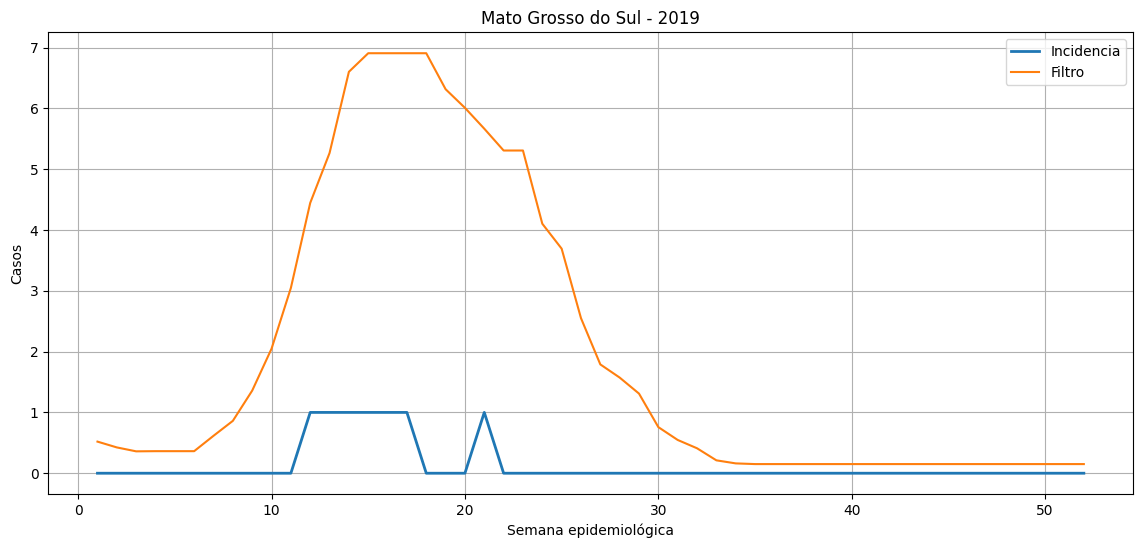

In [606]:
MS = filtrar_estado("MS")
M = filtrar_ano(MS, 2019)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul - 2019")
plt.grid(True)
plt.legend()

plt.show()

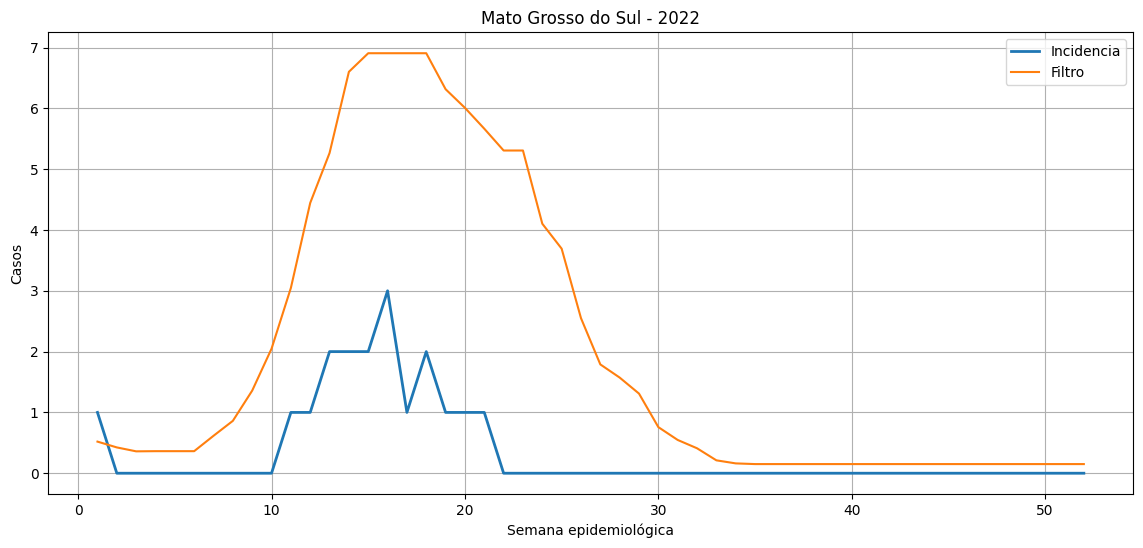

In [607]:
MS = filtrar_estado("MS")
M = filtrar_ano(MS, 2022)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul - 2022")
plt.grid(True)
plt.legend()

plt.show()

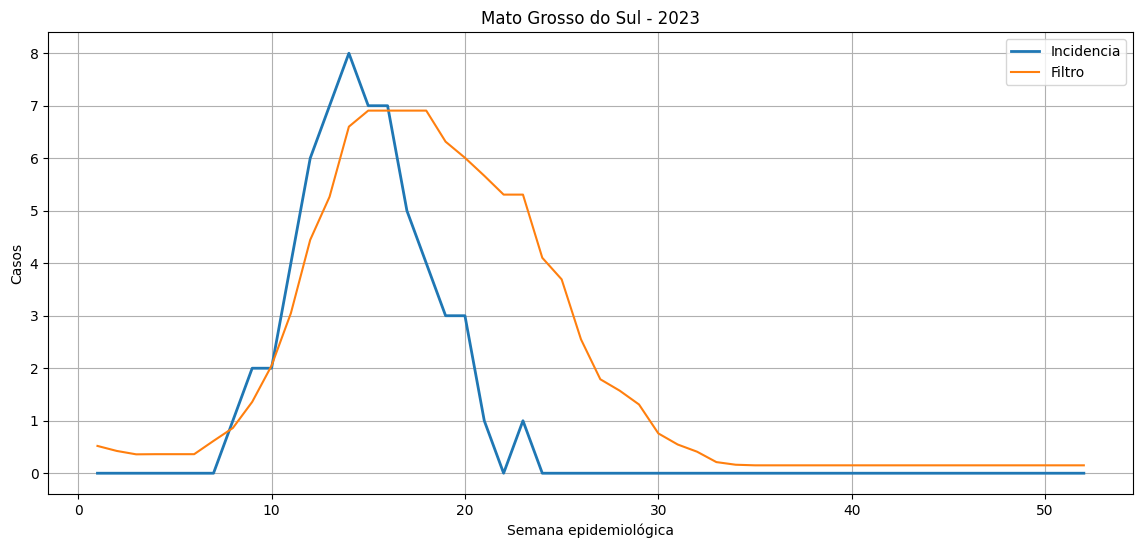

In [608]:
MS = filtrar_estado("MS")
M = filtrar_ano(MS, 2023)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul - 2023")
plt.grid(True)
plt.legend()

plt.show()

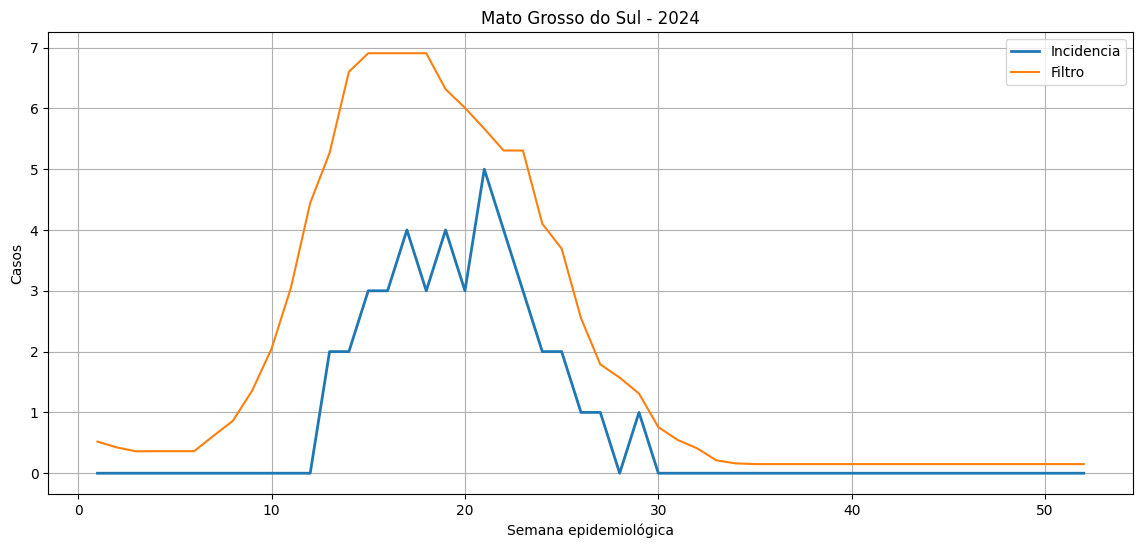

In [609]:
MS = filtrar_estado("MS")
M = filtrar_ano(MS, 2024)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul - 2024")
plt.grid(True)
plt.legend()

plt.show()

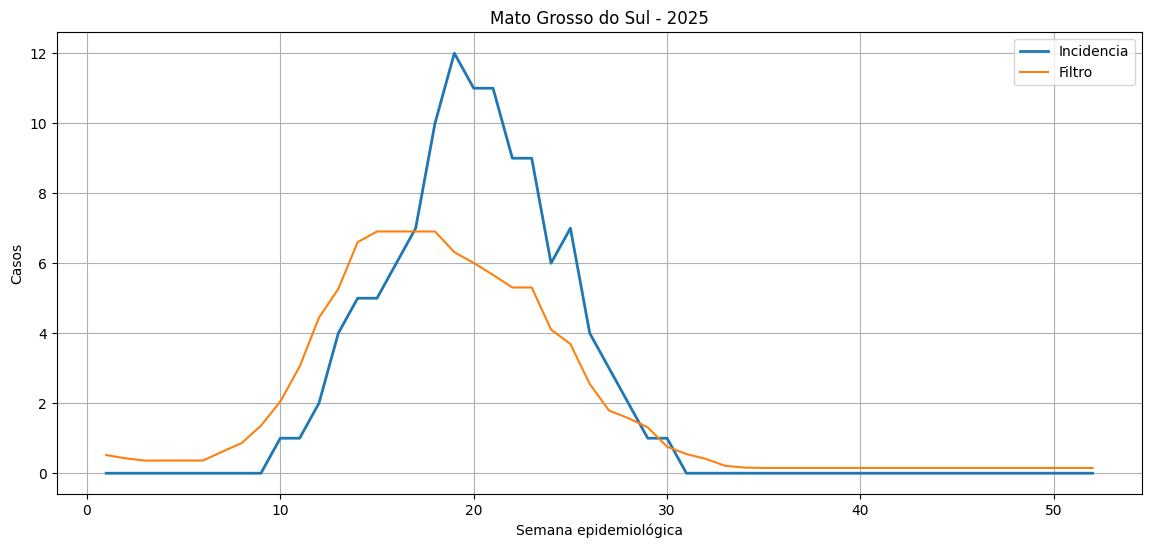

In [610]:
MS = filtrar_estado("MS")
M = filtrar_ano(MS, 2025)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(MS, semana), filtro3(MS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Mato Grosso do Sul - 2025")
plt.grid(True)
plt.legend()

plt.show()

### Rio de Janeiro

In [611]:
RJ = filtrar_estado('RJ')
RJ.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,RJ,2018,1,2,17264943.0,0.011584
1,RJ,2018,2,0,17264943.0,0.000000
2,RJ,2018,3,0,17264943.0,0.000000
3,RJ,2018,4,2,17264943.0,0.011584
4,RJ,2018,5,2,17264943.0,0.011584


In [612]:
ft1 = filtro1(RJ)
ft1

0.09089198795809658

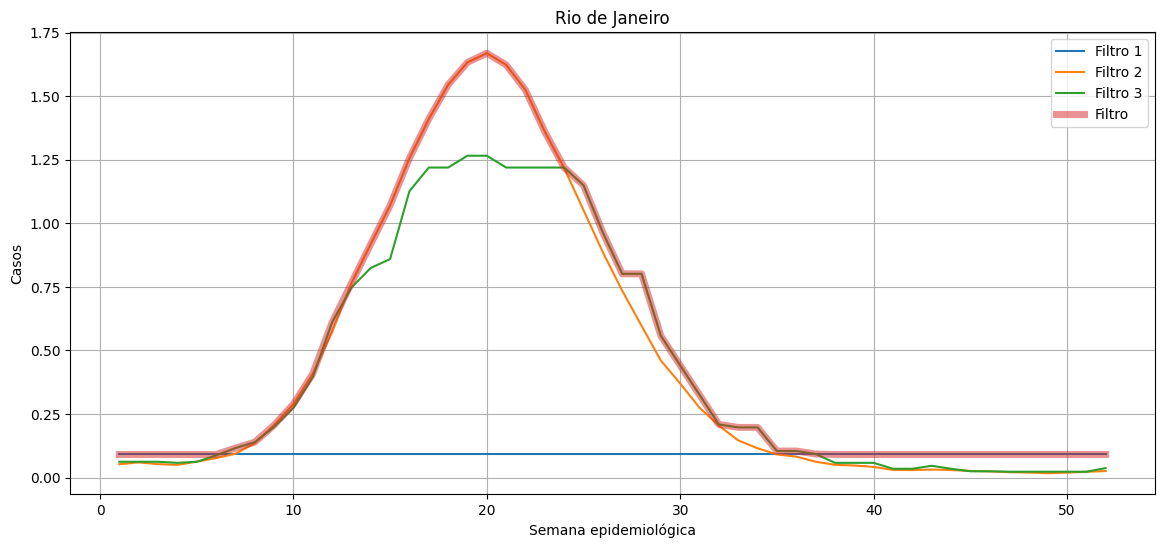

In [613]:
M = filtrar_ano(RJ, 2019)

semanas = []
f1 = []
f2 = []
f3 = []
f = []

for semana in range(1, 53):

    semanas.append(semana)

    f1.append(ft1)          # valor fixo
    f2.append(filtro2(RJ, semana))
    f3.append(filtro3(RJ, semana))
    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))
plt.plot(semanas, f1, label="Filtro 1")
plt.plot(semanas, f2, label="Filtro 2")
plt.plot(semanas, f3, label="Filtro 3")
plt.plot(semanas, f, label="Filtro", linewidth=5, alpha = 0.5)

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro")
plt.grid(True)
plt.legend()

plt.show()

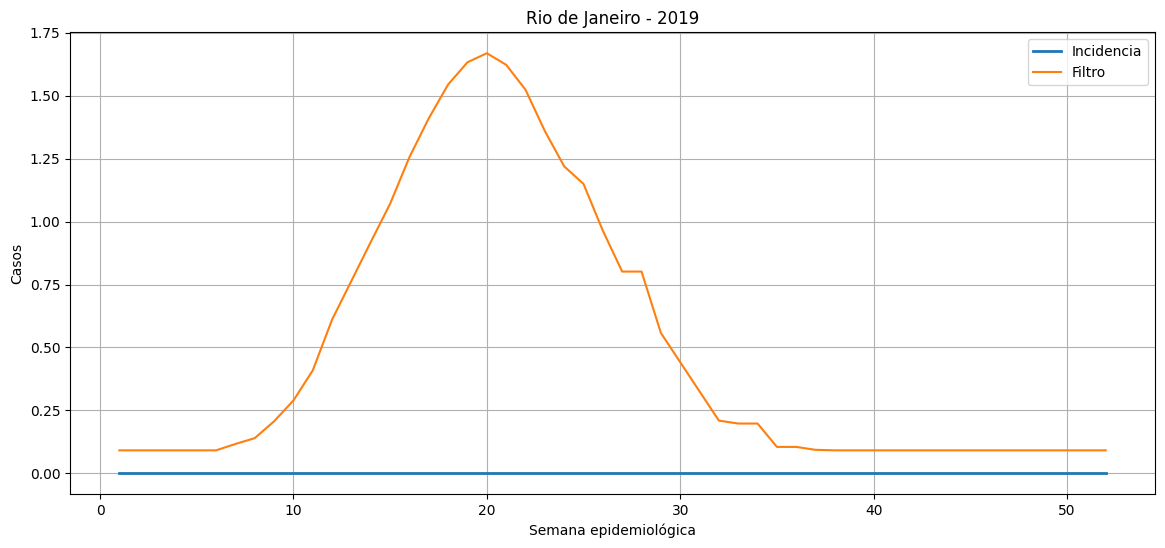

In [614]:
M = filtrar_ano(RJ, 2019)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro - 2019")
plt.grid(True)
plt.legend()

plt.show()

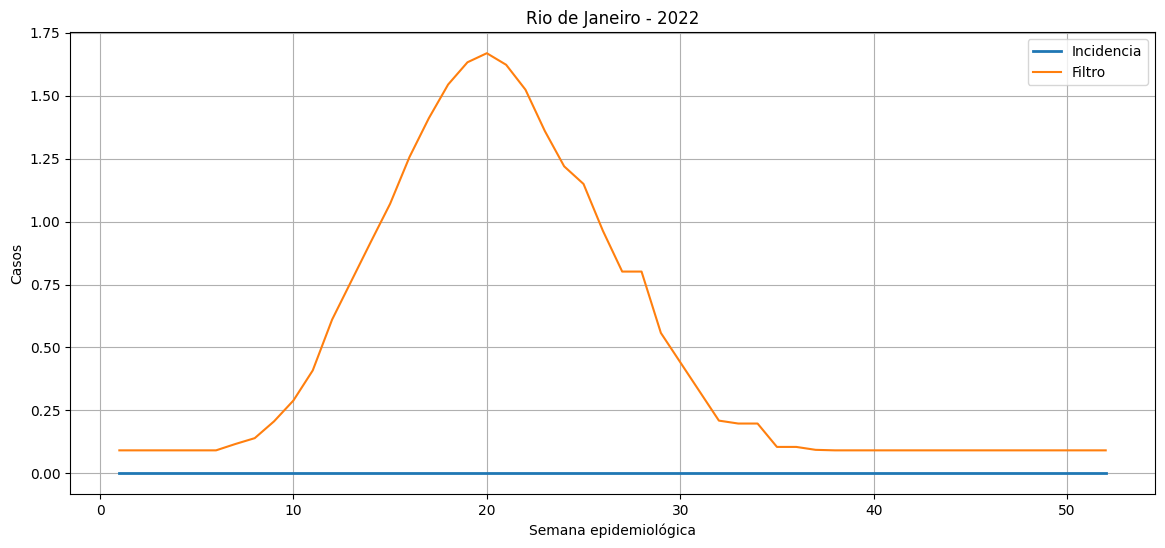

In [615]:
M = filtrar_ano(RJ, 2022)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro - 2022")
plt.grid(True)
plt.legend()

plt.show()

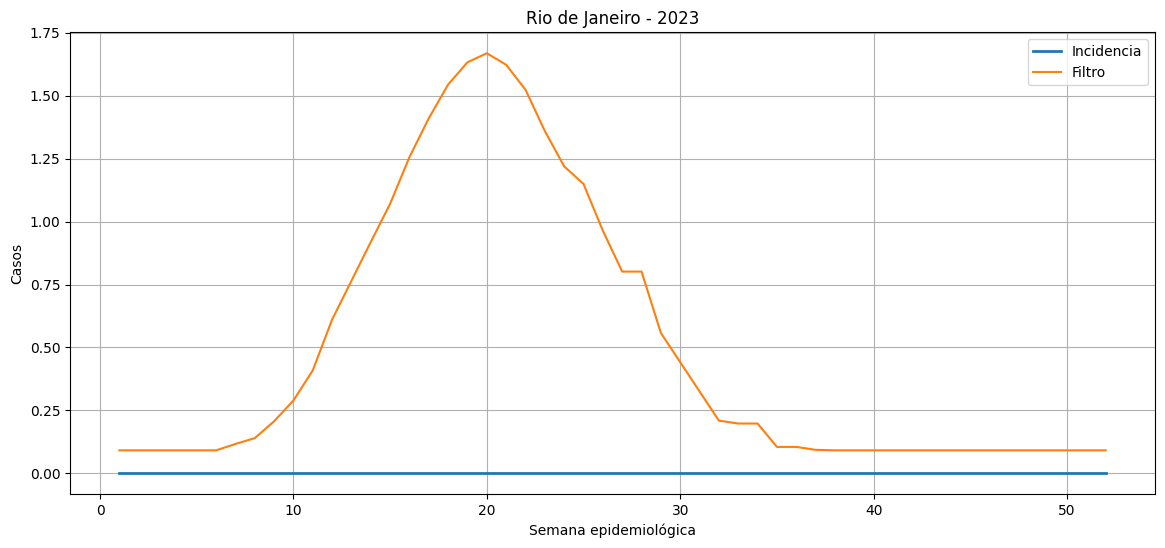

In [616]:
M = filtrar_ano(RJ, 2023)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro - 2023")
plt.grid(True)
plt.legend()

plt.show()

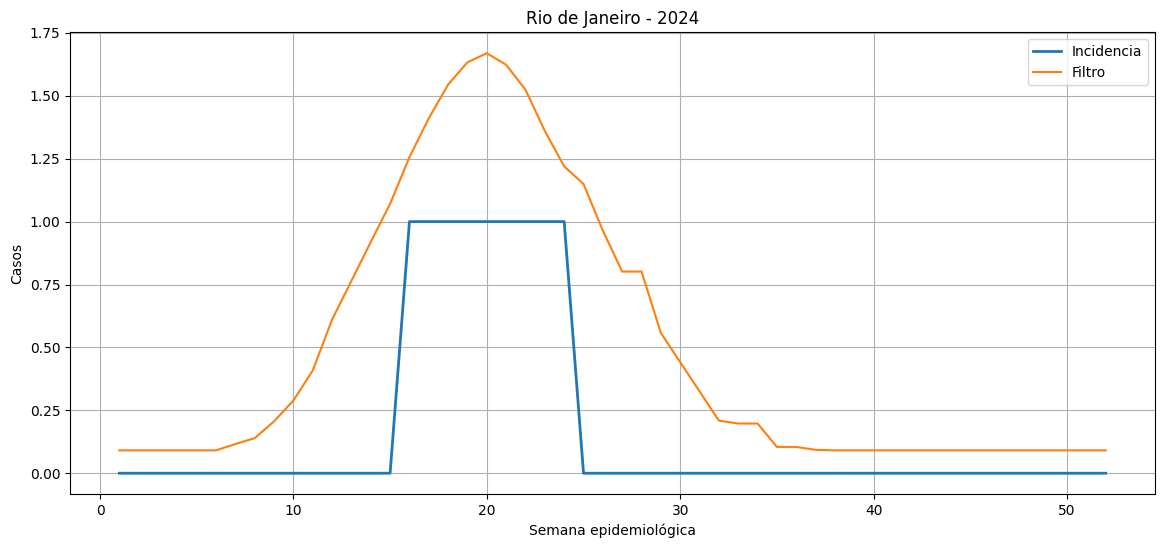

In [617]:
M = filtrar_ano(RJ, 2024)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro - 2024")
plt.grid(True)
plt.legend()

plt.show()

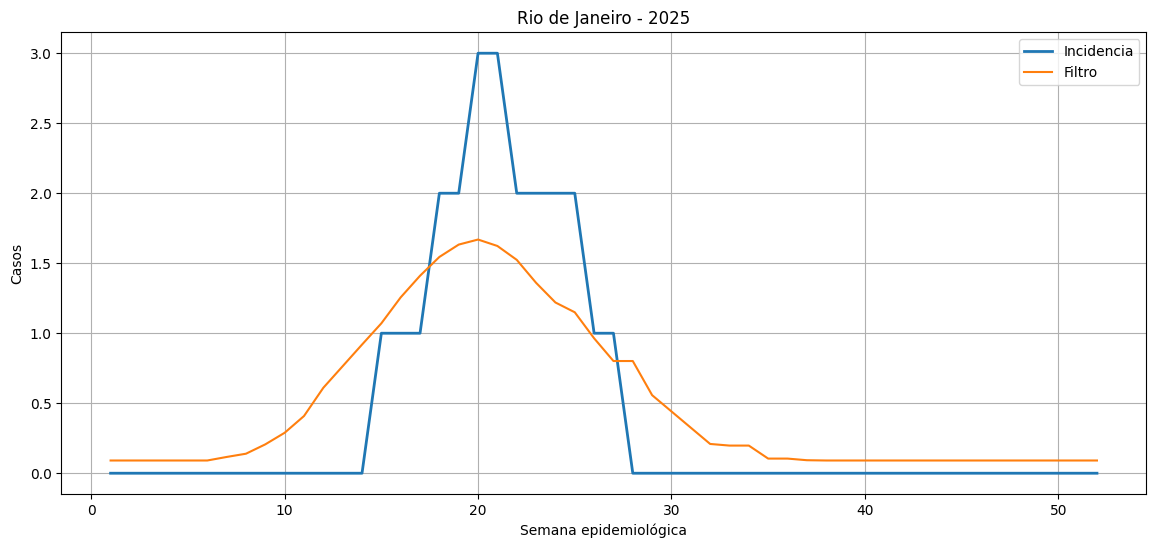

In [618]:
M = filtrar_ano(RJ, 2025)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio de Janeiro - 2025")
plt.grid(True)
plt.legend()

plt.show()

### Rio Grande do Sul

In [619]:
RS = filtrar_estado('RS')
RS.head()

,DS_UF_SIGLA,epiyear,epiweek,VSR,populacao,incidencia_por_100k
0,RS,2018,1,0,11377239.0,0.0
1,RS,2018,2,0,11377239.0,0.0
2,RS,2018,3,0,11377239.0,0.0
3,RS,2018,4,0,11377239.0,0.0
4,RS,2018,5,0,11377239.0,0.0


In [620]:
ft1 = filtro1(RS)
ft1

0.48905822079320294

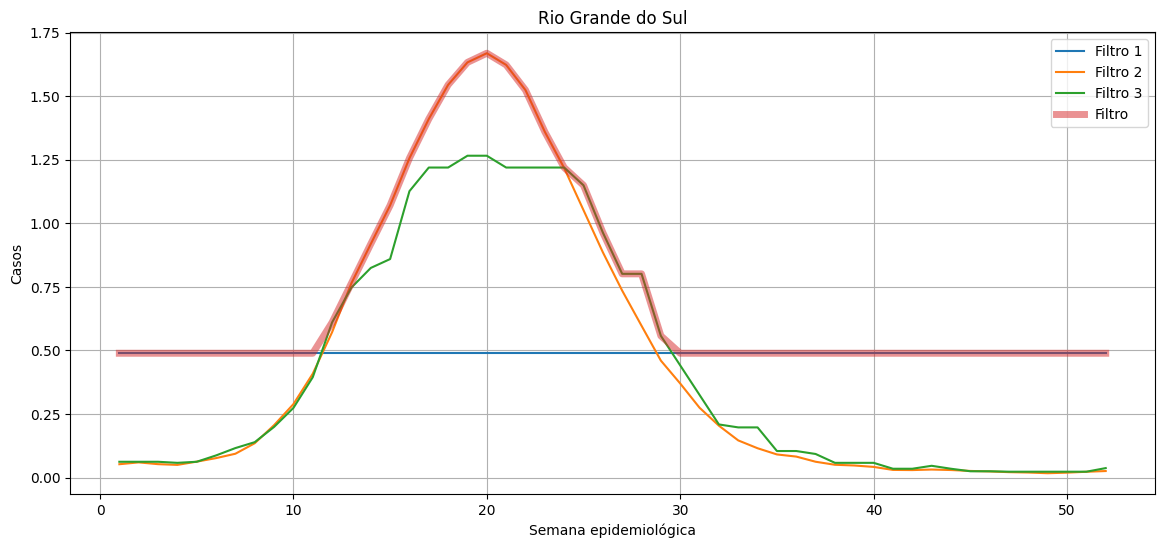

In [621]:
M = filtrar_ano(RS, 2019)

semanas = []
f1 = []
f2 = []
f3 = []
f = []

for semana in range(1, 53):

    semanas.append(semana)

    f1.append(ft1)          # valor fixo
    f2.append(filtro2(RJ, semana))
    f3.append(filtro3(RJ, semana))
    f.append(max(ft1, filtro2(RJ, semana), filtro3(RJ, semana)))

plt.figure(figsize=(14,6))
plt.plot(semanas, f1, label="Filtro 1")
plt.plot(semanas, f2, label="Filtro 2")
plt.plot(semanas, f3, label="Filtro 3")
plt.plot(semanas, f, label="Filtro", linewidth=5, alpha = 0.5)

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul")
plt.grid(True)
plt.legend()

plt.show()

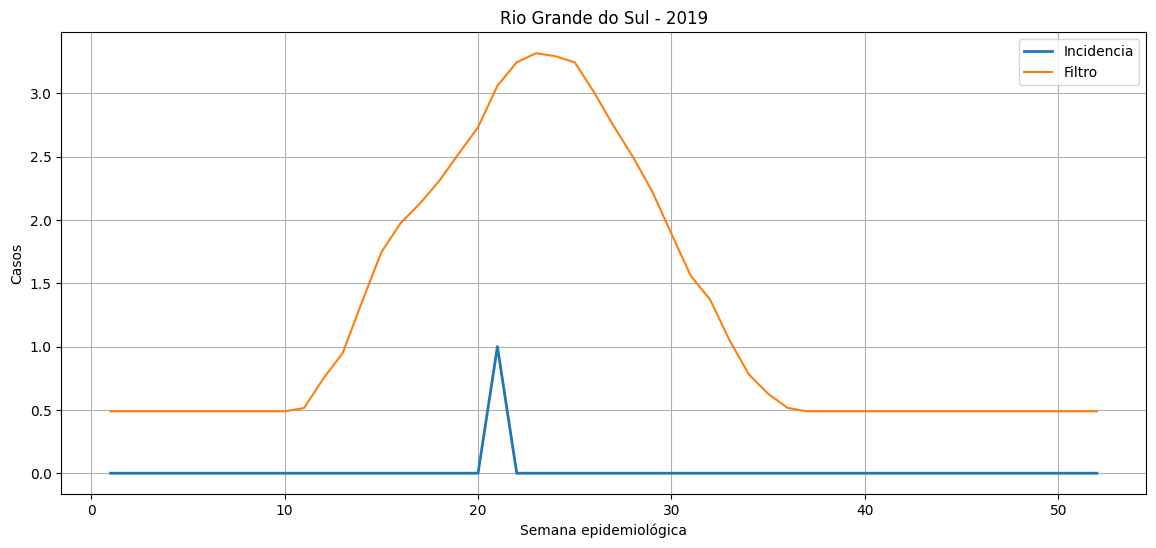

In [622]:
M = filtrar_ano(RS, 2019)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RS, semana), filtro3(RS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul - 2019")
plt.grid(True)
plt.legend()

plt.show()

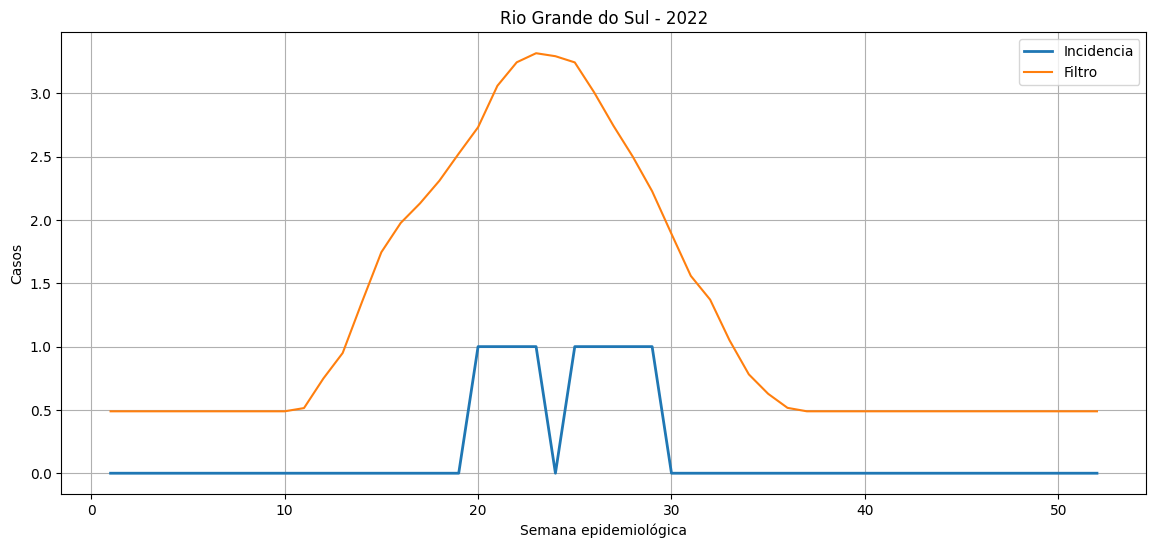

In [623]:
M = filtrar_ano(RS, 2022)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RS, semana), filtro3(RS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul - 2022")
plt.grid(True)
plt.legend()

plt.show()

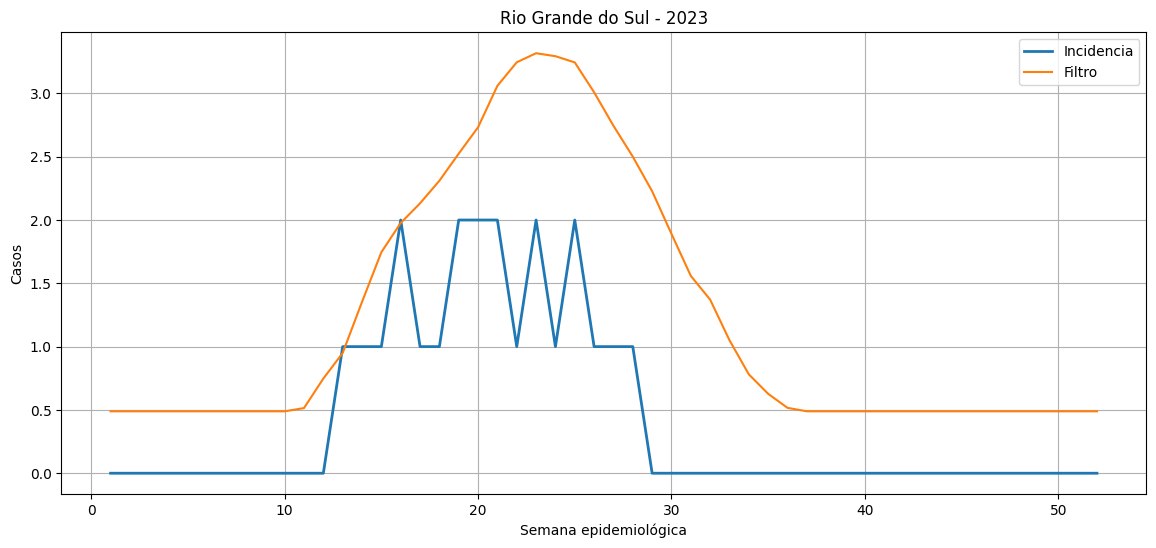

In [624]:
M = filtrar_ano(RS, 2023)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RS, semana), filtro3(RS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul - 2023")
plt.grid(True)
plt.legend()

plt.show()

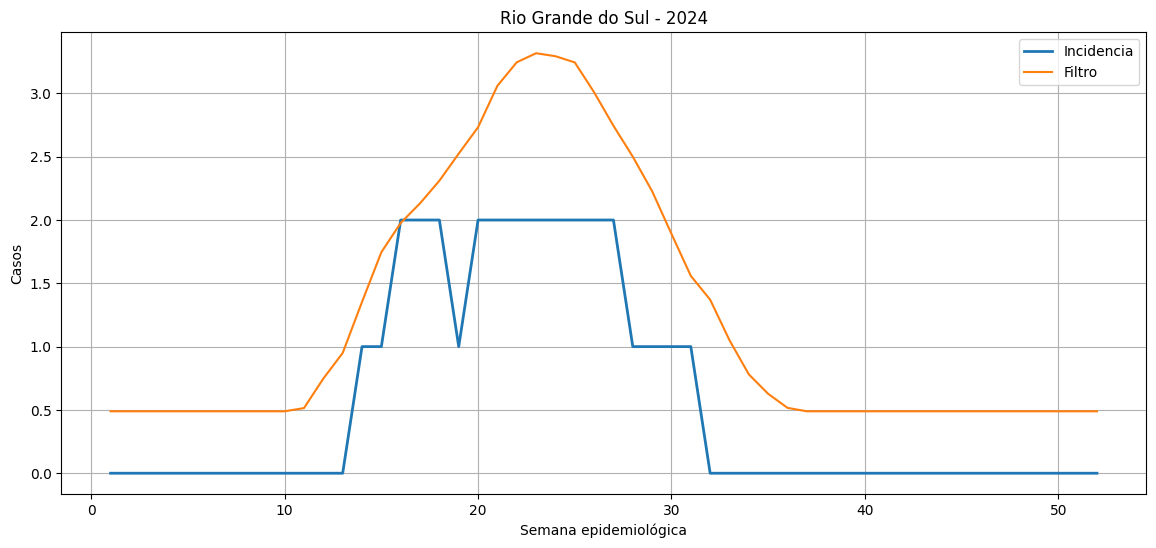

In [625]:
M = filtrar_ano(RS, 2024)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RS, semana), filtro3(RS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul - 2024")
plt.grid(True)
plt.legend()

plt.show()

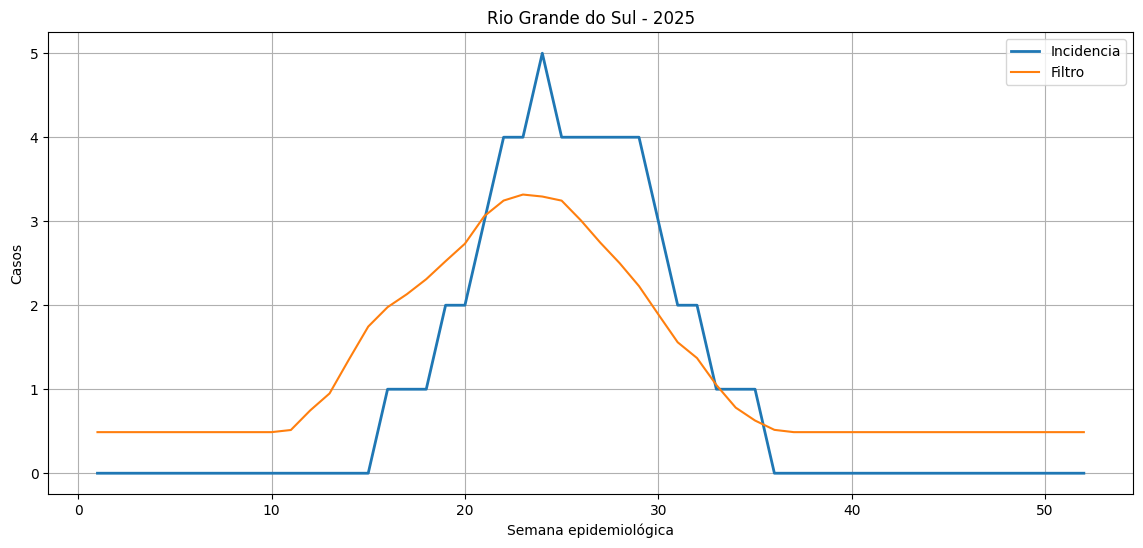

In [626]:
M = filtrar_ano(RS, 2025)

semanas = []
casos = []
f = []

for semana in range(1, 53):

    caso = int(M.loc[M["epiweek"] == semana, "incidencia_por_100k"].values[0])

    semanas.append(semana)
    casos.append(caso)

    f.append(max(ft1, filtro2(RS, semana), filtro3(RS, semana)))

plt.figure(figsize=(14,6))

plt.plot(semanas, casos, label="Incidencia", linewidth=2)
plt.plot(semanas, f, label="Filtro")

plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos")
plt.title("Rio Grande do Sul - 2025")
plt.grid(True)
plt.legend()

plt.show()